PREDIKSI CURAH HUJAN SUBSEASINAL TO SEASONAL

oleh: Ghazian Hirzi Hanafi, Kharir Frestia Deastari

#PREPROCESSING

##Useless

In [ ]:
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive/')

import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
path='/content/drive/My Drive/PCHS2s/'
# Load the precipitation netCDF data using xarray
data = xr.open_dataset(path+'chirpssumatera.nc')

# Extract the precipitation variable from the data
precipitation = data['precip']

# Reshape the precipitation data into a 2D array
precipitation_array = precipitation.values.reshape(precipitation.shape[0], -1)

# Perform PCA on the precipitation data
pca = PCA(n_components=0.9)
principal_components = pca.fit_transform(precipitation_array)

# Get the explained variance ratio of each principal component
explained_variance_ratio = pca.explained_variance_ratio_

# Plot the principal components
plt.figure(figsize=(8, 6))
plt.scatter(principal_components[:, 0], principal_components[:, 1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Principal Components Analysis')
plt.grid(True)
plt.show()


KeyboardInterrupt: ignored

In [ ]:
#xr.open_dataset(path+'chirpssumatera.nc')
!pip install eofs

In [ ]:
import numpy as np
import xarray as xr
from eofs.xarray import Eof
import matplotlib.pyplot as plt

# Load the NetCDF data using xarray
data =xr.open_dataset(path+'chirpssumatera.nc')
# Extract the precipitation variable
precip = data['precip']

# Apply cosine of latitude weights
weights = np.cos(np.deg2rad(precip['latitude'].values))
precip_weighted = precip * weights

# Perform EOF analysis
solver = Eof(precip_weighted)
eofs = solver.eofs(neofs=1)  # Number of desired EOFs

# Retrieve the explained variance ratio
explained_variance = solver.varianceFraction(neigs=1)[0]

# Plot the EOF result on a raster map
lon = data['longitude'].values
lat = data['latitude'].values
plt.pcolormesh(lon, lat, eofs[0, 0], cmap='RdBu_r')
plt.colorbar(label='EOF 1')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Explained Variance: {explained_variance:.2%}')
plt.show()


In [ ]:
#plt.imshow( pca_result, cmap='RdYlBu')
#plt.colorbar(label='PC1')
#plt.xlabel('Longitude')
#plt.ylabel('Latitude')
#plt.title('PCA - PC1')
#plt.show()
precip.to_array(dim='time')

In [ ]:
x=precipitation.to_dataframe().dropna()
data=x#.reset_index()
precipitation_data = data.iloc[:, 0:]
# Perform PCA on the precipitation data
pca = PCA(n_components=0.9)
principal_components = pca.fit_transform(precipitation_data)

# Create a DataFrame for the principal components
components_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# Get the explained variance ratio of each principal component
explained_variance_ratio = pca.explained_variance_ratio_
components_df


##Download Data (CHMODEL)

In [ ]:
#ECMWF
!pip install cdsapi
import cdsapi
url = 'url: https://cds.climate.copernicus.eu/api/v2'
key = 'key: 148805:5ea23c8e-fe9f-4c19-80e8-e3f6b56bac0d'
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive/')
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
path='/content/drive/My Drive/PCHS2s/'
pathmodel='/content/drive/My Drive/PCHS2s/MODEL/'
with open('/root/.cdsapirc', 'w') as f:
    f.write('\n'.join([url, key]))
with open('/root/.cdsapirc') as f:
    print(f.read())
c = cdsapi.Client()

satu=['01','04','07','10']
dua=['02','05','08','11']
tiga=['03','06','09','12']
bunal=[satu,dua,tiga]
satux='14710'
duax='25811'
tigax='36912'
bunalx=[satux,duax,tigax]

import cdsapi
c = cdsapi.Client()
for i in range(2010,2021):
  for x,vzz in zip(bunal,bunalx):
    c.retrieve(
        'seasonal-monthly-single-levels',
        {
            'originating_centre': 'ecmwf',
            'system': '5',
            'variable': 'total_precipitation',
            'product_type': 'monthly_mean',
            'year': f'{i}',
            'month': x
            ,
            'leadtime_month': [
                '1', '2', '3',
            ],
            'area': [
                10, 85, -10,
                142,
            ],
            'format': 'netcdf',
        },

        f'{pathmodel}ECMWF_S5_{i}MM{vzz}.nc')

  Preparing metadata (setup.py) ... done
  Created wheel for cdsapi: filename=cdsapi-0.6.1-py2.py3-none-any.whl size=12009 sha256=3876fca07cc32d17d7f51b0a4613b4b4a1dcf5b78c348ef0b680517c5318588e
  Stored in directory: /root/.cache/pip/wheels/7c/63/08/45461d6f6636c1aba7846828d8c787a064073945048f76d44a
Successfully built cdsapi


MessageError: ignored

In [1]:
#ECMWF
!pip install cdsapi
import cdsapi
url = 'url: https://cds.climate.copernicus.eu/api/v2'
url = 'url: https://cds.climate.copernicus.eu/api'
key = 'key: 148805:5ea23c8e-fe9f-4c19-80e8-e3f6b56bac0d'
key = 'key: bc0532a2-dfaa-4358-8a09-18c645bea092'
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive/')
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
path='/content/drive/My Drive/01_PCHS2s/'
pathmodel='/content/drive/My Drive/01_PCHS2s/MODEL/'
with open('/root/.cdsapirc', 'w') as f:
    f.write('\n'.join([url, key]))
with open('/root/.cdsapirc') as f:
    print(f.read())
c = cdsapi.Client()

satu=['01','04','07','10']
dua=['02','05','08','11']
tiga=['03','06','09','12']
bunal=[satu,dua,tiga]
satux='14710'
duax='25811'
tigax='36912'
bunalx=[satux,duax,tigax]

import cdsapi
c = cdsapi.Client()
x=6
xy=[]
for i in range(x,x+5160,6):
  xy.append(str(i))
import cdsapi

dataset = "seasonal-original-single-levels"
request = {
    "originating_centre": "ecmwf",
    "system": "51",
    "variable": [
        "2m_dewpoint_temperature",
        "2m_temperature"
    ],
    "year": ["2024"],
    "month": ["11"],
    "day": ["01"],
    "leadtime_hour": xy,
    "data_format": "netcdf",
    "area": [15, 90, -15, 145]
}
target=f"{pathmodel}ECMWF_202411F6.nc"
client = cdsapi.Client()
c.retrieve(dataset, request,target)#.download()


  Preparing metadata (setup.py) ... done
  Created wheel for multiurl: filename=multiurl-0.3.2-py3-none-any.whl size=21238 sha256=8f63ad4d7a2cbd0feb6ca4c64b3be9ce74dd409479867debe7ae7f7092aac4cd
  Stored in directory: /root/.cache/pip/wheels/6a/a4/4d/4290aa85d06f3885093ca0f50fcda5ecc9198c9dad84c8cb65
Successfully built multiurl
Mounted at /content/drive/
url: https://cds.climate.copernicus.eu/api
key: bc0532a2-dfaa-4358-8a09-18c645bea092


2024-11-10 00:43:44,803 INFO [2024-09-28T00:00:00] **Welcome to the New Climate Data Store (CDS)!** This new system is in its early days of full operations and still undergoing enhancements and fine tuning. Some disruptions are to be expected. Your 
[feedback](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202) is key to improve the user experience on the new CDS for the benefit of everyone. Thank you.
INFO:cads_api_client.legacy_api_client:[2024-09-28T00:00:00] **Welcome to the New Climate Data Store (CDS)!** This new system is in its early days of full operations and still undergoing enhancements and fine tuning. Some disruptions are to be expected. Your 
[feedback](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202) is key to improve the user experience on the new CDS for the benefit of everyone. Thank you.
2024-11-10 00:43:44,808 WARNING [2024-09-26T00:00:00] Should you have not yet migrated from the old CDS system to the new CDS, please check our [informa

d69410fa9fea19462c40b0063de7b60.nc:   0%|          | 0.00/318M [00:00<?, ?B/s]

'/content/drive/My Drive/01_PCHS2s/MODEL/ECMWF_202411F6.nc'

In [2]:
#ECMWF
!pip install netcdf4
!pip install h5netcdf
!pip install xarray[io]
import pandas as pd
import os

from google.colab import drive
drive.mount('/content/drive/')
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import xarray as xr
#path = os.getcwd()+"/data/"
path='/content/drive/My Drive/01_PCHS2s/'
pathmodel='/content/drive/My Drive/01_PCHS2s/MODEL/'
dset = xr.open_dataset(pathmodel+"ECMWF_202411F6.nc")
dset


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 67.5 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5034 sha256=6b41a904e78401ab72985c9e33d8d1bb8def486395e4fadaec0495422fbadb04
  Stored in directory: /root/.cache/pip/wheels/7f/4e/be/1171b40f43b918087657ec57cf3b81fa1a2e027d8755baa184
Successfully built asciitree
Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


<xarray.Dataset> Size: 609MB
Dimensions:                  (number: 51, forecast_reference_time: 1,
                              forecast_period: 860, latitude: 31, longitude: 56)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 8B 2024...
  * forecast_period          (forecast_period) timedelta64[ns] 7kB 0 days 06:...
  * latitude                 (latitude) float64 248B 15.0 14.0 ... -14.0 -15.0
  * longitude                (longitude) float64 448B 90.0 91.0 ... 144.0 145.0
    valid_time               (forecast_period) datetime64[ns] 7kB ...
Data variables:
    d2m                      (number, forecast_reference_time, forecast_period, latitude, longitude) float32 305MB ...
    t2m                      (number, forecast_reference_time, forecast_period, latitude, longitude) float32 305MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-11-09T21:55 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
#JMA
!pip install cdsapi
import cdsapi
url = 'url: https://cds.climate.copernicus.eu/api/v2'
key = 'key: 148805:5ea23c8e-fe9f-4c19-80e8-e3f6b56bac0d'
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive/')
pathmodel='/content/drive/My Drive/PCHS2s/MODEL/'
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
path='/content/drive/My Drive/PCHS2s/'
with open('/root/.cdsapirc', 'w') as f:
    f.write('\n'.join([url, key]))
with open('/root/.cdsapirc') as f:
    print(f.read())
c = cdsapi.Client()

import cdsapi

c = cdsapi.Client()
for i in range(2010,2021):
  for x,vzz in zip(bunal,bunalx):
    c.retrieve(
        'seasonal-monthly-single-levels',
        {
            'originating_centre': 'jma',
            'system': '3',
            'variable': 'total_precipitation',
            'product_type': 'monthly_mean',
            'year': f'{i}',
            'month': x,
            'leadtime_month': [
                '1', '2', '3',
            ],
            'area': [
                10, 85, -10,
                142,
            ],
            'format': 'netcdf',
        },
      f'{pathmodel}JMA_S3_{i}MM{vzz}.nc')

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


2023-05-29 11:52:19,302 INFO Welcome to the CDS
INFO:cdsapi:Welcome to the CDS
2023-05-29 11:52:19,306 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/seasonal-monthly-single-levels
INFO:cdsapi:Sending request to https://cds.climate.copernicus.eu/api/v2/resources/seasonal-monthly-single-levels


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
url: https://cds.climate.copernicus.eu/api/v2
key: 148805:5ea23c8e-fe9f-4c19-80e8-e3f6b56bac0d


2023-05-29 11:52:19,487 INFO Request is completed
INFO:cdsapi:Request is completed
2023-05-29 11:52:19,492 INFO Downloading https://download-0007-clone.copernicus-climate.eu/cache-compute-0007/cache/data6/adaptor.mars.external-1685360289.7943382-22524-16-c4012e3b-ba26-4605-80ec-0f6a52f704bb.nc to /content/drive/My Drive/PCHS2s/MODEL/JMA_S3_2010MM14710.nc (184.8K)
INFO:cdsapi:Downloading https://download-0007-clone.copernicus-climate.eu/cache-compute-0007/cache/data6/adaptor.mars.external-1685360289.7943382-22524-16-c4012e3b-ba26-4605-80ec-0f6a52f704bb.nc to /content/drive/My Drive/PCHS2s/MODEL/JMA_S3_2010MM14710.nc (184.8K)
2023-05-29 11:52:20,271 INFO Download rate 238.2K/s
INFO:cdsapi:Download rate 238.2K/s
2023-05-29 11:52:20,481 INFO Welcome to the CDS
INFO:cdsapi:Welcome to the CDS
2023-05-29 11:52:20,485 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/seasonal-monthly-single-levels
INFO:cdsapi:Sending request to https://cds.climate.copernicus.eu/api/v2/

In [ ]:
#ECCC
!pip install cdsapi
import cdsapi
url = 'url: https://cds.climate.copernicus.eu/api/v2'
key = 'key: 148805:5ea23c8e-fe9f-4c19-80e8-e3f6b56bac0d'
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive/')
pathmodel='/content/drive/My Drive/PCHS2s/MODEL/'
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
path='/content/drive/My Drive/PCHS2s/'
with open('/root/.cdsapirc', 'w') as f:
    f.write('\n'.join([url, key]))
with open('/root/.cdsapirc') as f:
    print(f.read())
c = cdsapi.Client()
import cdsapi

c = cdsapi.Client()
for i in range(2010,2021):
  for x,vzz in zip(bunal,bunalx):
    c.retrieve(
        'seasonal-monthly-single-levels',
        {
            'originating_centre': 'eccc',
            'system': '3',
            'variable': 'total_precipitation',
            'product_type': 'monthly_mean',
            'year': f'{i}',
            'month': x,
            'leadtime_month': [
                '1', '2', '3',
            ],
            'area': [
                10, 85, -10,
                142,
            ],
            'format': 'netcdf',
        },
        f'{pathmodel}ECCC_S3_{i}MM{vzz}.nc')

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


2023-05-29 11:55:56,838 INFO Welcome to the CDS
INFO:cdsapi:Welcome to the CDS
2023-05-29 11:55:56,856 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/seasonal-monthly-single-levels
INFO:cdsapi:Sending request to https://cds.climate.copernicus.eu/api/v2/resources/seasonal-monthly-single-levels


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
url: https://cds.climate.copernicus.eu/api/v2
key: 148805:5ea23c8e-fe9f-4c19-80e8-e3f6b56bac0d


2023-05-29 11:55:57,118 INFO Request is completed
INFO:cdsapi:Request is completed
2023-05-29 11:55:57,129 INFO Downloading https://download-0008-clone.copernicus-climate.eu/cache-compute-0008/cache/data2/adaptor.mars.external-1685360344.8205717-18114-19-abecdd55-5eb0-4b3a-a790-f5853a673c7f.nc to /content/drive/My Drive/PCHS2s/MODEL/ECCC_S3_2010MM14710.nc (287K)
INFO:cdsapi:Downloading https://download-0008-clone.copernicus-climate.eu/cache-compute-0008/cache/data2/adaptor.mars.external-1685360344.8205717-18114-19-abecdd55-5eb0-4b3a-a790-f5853a673c7f.nc to /content/drive/My Drive/PCHS2s/MODEL/ECCC_S3_2010MM14710.nc (287K)
2023-05-29 11:55:57,686 INFO Download rate 524.9K/s
INFO:cdsapi:Download rate 524.9K/s
2023-05-29 11:55:57,951 INFO Welcome to the CDS
INFO:cdsapi:Welcome to the CDS
2023-05-29 11:55:57,958 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/seasonal-monthly-single-levels
INFO:cdsapi:Sending request to https://cds.climate.copernicus.eu/api/v2/re

In [ ]:
#BUKA DATA
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive/')
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
path='/content/drive/My Drive/PCHS2s/'
pathmodel='/content/drive/My Drive/PCHS2s/MODEL/'
os.listdir(path)
ecmwfnc='ECMWF_S5_2011MM36912L123.nc'
jmanc='ECCC_S3_2011MM36912.nc'
#ceke=xr.open_dataset(path+ecmwfnc)
cekj=xr.open_dataset(pathmodel+jmanc)
cekj
#cek
#cek['tprate']=cek['tprate']*86400000#.to_dataframe()
#cek=cek.isel(time=2)
##cek=cek.isel(number=2)
#cek.to_dataframe()
#.tprate.plot()#.to_dataframe()
#

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


<xarray.Dataset>
Dimensions:    (longitude: 58, latitude: 21, number: 10, time: 12)
Coordinates:
  * longitude  (longitude) float32 85.0 86.0 87.0 88.0 ... 140.0 141.0 142.0
  * latitude   (latitude) float32 10.0 9.0 8.0 7.0 6.0 ... -7.0 -8.0 -9.0 -10.0
  * number     (number) int32 0 1 2 3 4 5 6 7 8 9
  * time       (time) datetime64[ns] 2011-03-01 2011-04-01 ... 2012-02-01
Data variables:
    tprate     (time, number, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2023-05-28 23:45:42 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

##Merge Data

In [ ]:
import pandas as pd
import os
from google.colab import drive
drive.mount('/content/drive/')
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pathmodel='/content/drive/My Drive/PCHS2s/MODEL/'
path='/content/drive/My Drive/PCHS2s/'
import os
import xarray as xr
# Get a list of all .nc files starting with 'ECMWF'
ECMWF = [file for file in os.listdir(pathmodel) if file.startswith('ECMWF')]
ECCC = [file for file in os.listdir(pathmodel) if file.startswith('ECCC')]
JMA = [file for file in os.listdir(pathmodel) if file.startswith('JMA')]
#ECMWF = [file for file in os.listdir(pathmodel) if file.startswith('ECMWF')]
coba=[ECMWF,ECCC,JMA]
nama=['ECMWF','ECCC','JMA']
for i,x in zip(coba,nama):
#variabel=ECMWF
  datasets = []
  for file in i:
      file_path = os.path.join(pathmodel, file)
      dataset = xr.open_dataset(file_path)
      dataset=dataset.isel(time=[0,3,6,9])
      datasets.append(dataset)
  combined_dataset = xr.concat(datasets, dim='time')
  output_path = f'{path}{x}1120_L3.nc'
  combined_dataset.to_netcdf(output_path)

Mounted at /content/drive/


FileNotFoundError: ignored

#Process Data

In [ ]:
import pandas as pd
#!pip install geopandas
#!pip install cartopy
import os
from google.colab import drive
drive.mount('/content/drive/')
import xarray as xr
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pathmodel='/content/drive/My Drive/PCHS2s/MODEL/'
jmakcl='JMA_S3_2011MM14710.nc'
path='/content/drive/My Drive/PCHS2s/'
pathshp='/content/drive/My Drive/PCHS2s/ZOM_INDONESIA/'
import os
import xarray as xr
#os.listdir(pathmodel)
#os.listdir(path)
jma='JMA1120_L1.nc'
ecmwf='ECMWF1120_L1.nc'
eccc='ECCC1120_L1.nc'
obs='chirpssumatera.nc'
djma=xr.open_dataset(path+jma)
decmwf=xr.open_dataset(path+ecmwf)
deccc=xr.open_dataset(path+eccc)
dobs=xr.open_dataset(path+obs)
#djmakl=xr.open_dataset(pathmodel+jmakcl)
#djma=djma.isel(number=7)
#djma=djma.sel(longitude=139,latitude=-8,method='nearest')
##djmakl.to_dataframe()
#djma#.to_dataframe()
def ensemrata(data):#RATA-RATA ENSEMBLE MEMBER, SOALNYA GAK TAU CARA YANG PAS BUAT MILIH HEHE
  data= data.sortby('time')
  data=data.groupby('number').apply(lambda x: x.resample(time='1M').mean()).mean(dim='number')
  return(data)
drjma=ensemrata(djma)
drecmwf=ensemrata(decmwf)
dreccc=ensemrata(deccc)
drjma
drecmwf
dobs
deccc

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


<xarray.Dataset>
Dimensions:    (time: 132, number: 10, latitude: 21, longitude: 58)
Coordinates:
  * time       (time) datetime64[ns] 2010-02-01 2010-05-01 ... 2021-01-01
  * longitude  (longitude) float32 85.0 86.0 87.0 88.0 ... 140.0 141.0 142.0
  * latitude   (latitude) float32 10.0 9.0 8.0 7.0 6.0 ... -7.0 -8.0 -9.0 -10.0
  * number     (number) int32 0 1 2 3 4 5 6 7 8 9
Data variables:
    tprate     (time, number, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2023-05-29 11:39:05 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

##Potong Sumatera

In [ ]:
drsmtrecmwf=drecmwf.where((90 < drecmwf.longitude) & (drecmwf.longitude < 110) & (-7 < drecmwf.latitude)&(drecmwf.latitude < 8), drop=True)#potongsumatera
drsmtreccc=dreccc.where((90 < dreccc.longitude) & (dreccc.longitude < 110) & (-7 < dreccc.latitude)&(dreccc.latitude < 8), drop=True)#potongsumatera
#drsmtro=dobs.where((90 < dobs.longitude) & (dobs.longitude < 110) & (-7 < dobs.latitude)&(dobs.latitude < 8), drop=True)#potongsumatera
drsmtrjma=drjma.where((90 < drjma.longitude) & (drjma.longitude < 110) & (-7 < drjma.latitude)&(drjma.latitude < 8), drop=True)#potongsumatera
drsmtrecmwf.to_netcdf(path+'drsmtrecmwf1120.nc')
drsmtreccc.to_netcdf(path+'drsmtreccc1120.nc')
drsmtrjma.to_netcdf(path+'drsmtrjma1120.nc')

##Hutan Acak Dung dung tak dung dung

In [ ]:
!pip install cartopy
!pip install geopandas
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
drecc=dreccc.isel(time=2)
drecc['tprate']=drecc['tprate']*86400000*30
shapefile = gpd.read_file(f'{pathshp}ZOM9120_INDONESIA.shp')
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
pchclor='#720000','#A83800','#E54B01','#FFAA01','#FFFF00','#AAFF01','#4DE600','#70A701','#267300'
# Plot the shapefile lines
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
drecc.tprate.plot(ax=ax,levels=[0,20, 50, 100, 150, 200, 300, 400, 500],colors=pchclor)#,cax=cax)
shapefile.plot(ax=ax, linewidth=0.3, edgecolor='black',facecolor='none')
plt.show()

In [ ]:
import os
from google.colab import drive
import os
import pandas as pd
import xarray as xr
drive.mount('/content/drive/')
path='/content/drive/My Drive/PCHS2s/'
os.listdir(path)
drsmtrecmwf=xr.open_dataset(path+'drsmtrecmwf1120.nc')
drsmtreccc=xr.open_dataset(path+'drsmtreccc1120.nc')
drsmtrjma=xr.open_dataset(path+'drsmtrjma1120.nc')
dobs=xr.open_dataset(path+'chirpssumatera.nc')
#dobs=xr.open_dataset(path+'chirpspapua.nc')
lon,lat=100,-0
dbkttg_ecmwf=drsmtrecmwf.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_eccc=drsmtreccc.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_jma=drsmtrjma.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_obs=dobs.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_ecmwfdf=dbkttg_ecmwf.to_dataframe()
dbkttg_ecccdf=dbkttg_eccc.to_dataframe()
dbkttg_jmadf=dbkttg_jma.to_dataframe()
dbkttg_obsdf=dbkttg_obs.to_dataframe()
dbkttg_ecmwfdf=dbkttg_ecmwfdf.loc[(dbkttg_ecmwfdf.index >= '2011-01-01') & (dbkttg_ecmwfdf.index <'2021-01-01')]
dbkttg_ecccdf=dbkttg_ecccdf.loc[(dbkttg_ecccdf.index >= '2011-01-01') & (dbkttg_ecccdf.index <'2021-01-01')]
dbkttg_jmadf=dbkttg_jmadf.loc[(dbkttg_jmadf.index >= '2011-01-01') & (dbkttg_jmadf.index <'2021-01-01')]
dbkttg_obsdf=dbkttg_obsdf.loc[(dbkttg_obsdf.index >= '2011-01-01') & (dbkttg_obsdf.index <'2021-01-01')]
#dbkttg_ecmwfdf
#dbkttg_ecccdf
#dbkttg_jmadf
#dbkttg_obsdf
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
data=pd.DataFrame()
data['ECMWF']=dbkttg_ecmwfdf.reset_index()['tprate']*86400000*30
data['ECCC']=dbkttg_ecccdf.reset_index()['tprate']*86400000*30
data['JMA']=dbkttg_jmadf.reset_index()['tprate']*86400000*30
data['Observation']=dbkttg_obsdf.reset_index()['precip']
# Separate the predictor variables (ECCC, ECMWF, JMA) and the target variable (Observation)
X = data[['ECCC', 'ECMWF', 'JMA']]
y = data['Observation']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=120, random_state=0)

# Create a Random Forest regressor with default parameters
rf = RandomForestRegressor()#n_estimators=360,criterion='absolute_error')

# Train the model
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Mean Squared Error: 19991.84863403837
R2 Score: 0.021845448939781575


In [ ]:
#y_predT2#P1(LON,LAT)=100,-0 Korelasi=-0.585;Mean Squared Error: 18634.13788965862
#y_predT3#P1(LON,LAT)=100,-0; Korelasi=-0.4912707174501054;Mean Squared Error: 17528.13788965862
#y_predT4#P1(LON,LAT)=100,-0; Korelasi=-0.5222407344227704;Mean Squared Error: 17892.154108571674
y_test

8      343.470703
61     135.932510
90     114.314331
106    472.449799
71     386.172424
          ...    
12     313.471008
129    431.038635
88     378.355347
70     517.674927
87     423.925507
Name: Observation, Length: 120, dtype: float32

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Dominant Predictor: ECCC
Root Mean Squared Error: 137.13492467683034
Root Mean Squared Error ECMWF: 148.6554516300438
Root Mean Squared Error ECCC: 163.77567910708845
Root Mean Squared Error JMA: 159.2686336978856
Correlation: -0.16586376487854515


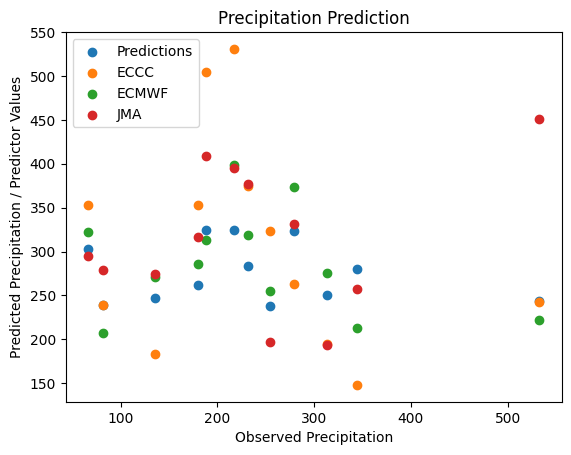

In [ ]:
import os
from google.colab import drive
import os
import pandas as pd
import xarray as xr
drive.mount('/content/drive/')
path='/content/drive/My Drive/PCHS2s/'
os.listdir(path)
drsmtrecmwf=xr.open_dataset(path+'drsmtrecmwf1120.nc')
drsmtreccc=xr.open_dataset(path+'drsmtreccc1120.nc')
drsmtrjma=xr.open_dataset(path+'drsmtrjma1120.nc')
dobs=xr.open_dataset(path+'chirpssumatera.nc')
#dobs=xr.open_dataset(path+'chirpspapua.nc')
lon,lat=100,-0
dbkttg_ecmwf=drsmtrecmwf.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_eccc=drsmtreccc.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_jma=drsmtrjma.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_obs=dobs.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_ecmwfdf=dbkttg_ecmwf.to_dataframe()
dbkttg_ecccdf=dbkttg_eccc.to_dataframe()
dbkttg_jmadf=dbkttg_jma.to_dataframe()
dbkttg_obsdf=dbkttg_obs.to_dataframe()
dbkttg_ecmwfdf=dbkttg_ecmwfdf.loc[(dbkttg_ecmwfdf.index >= '2011-01-01') & (dbkttg_ecmwfdf.index <'2021-01-01')]
dbkttg_ecccdf=dbkttg_ecccdf.loc[(dbkttg_ecccdf.index >= '2011-01-01') & (dbkttg_ecccdf.index <'2021-01-01')]
dbkttg_jmadf=dbkttg_jmadf.loc[(dbkttg_jmadf.index >= '2011-01-01') & (dbkttg_jmadf.index <'2021-01-01')]
dbkttg_obsdf=dbkttg_obsdf.loc[(dbkttg_obsdf.index >= '2011-01-01') & (dbkttg_obsdf.index <'2021-01-01')]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
data=pd.DataFrame()
data['ECMWF']=dbkttg_ecmwfdf.reset_index()['tprate']*86400000*30
data['ECCC']=dbkttg_ecccdf.reset_index()['tprate']*86400000*30
data['JMA']=dbkttg_jmadf.reset_index()['tprate']*86400000*30
data['Observation']=dbkttg_obsdf.reset_index()['precip']
# Separate the predictor variables (ECCC, ECMWF, JMA) and the target variable (Precipitation)
X = data[['ECCC', 'ECMWF', 'JMA']]
y = data['Observation']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=12, random_state=1000)

# Create a Random Forest regressor with default parameters
rf = RandomForestRegressor(max_leaf_nodes=7,warm_start=True,max_depth=7,min_samples_leaf=1)

# Train the model
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Calculate RMSE and correlation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmsecmwf = np.sqrt(mean_squared_error(data['ECMWF'], y))
rmseccc = np.sqrt(mean_squared_error(data['ECCC'], y))
rmsejma = np.sqrt(mean_squared_error(data['JMA'], y))
correlation = np.corrcoef(y_test, y_pred)[0, 1]

# Get feature importances
importance = rf.feature_importances_

# Find the dominant predictor
dominant_predictor = X.columns[np.argmax(importance)]
print('Dominant Predictor:', dominant_predictor)

print('Root Mean Squared Error:', rmse)
print('Root Mean Squared Error ECMWF:', rmsecmwf)
print('Root Mean Squared Error ECCC:', rmseccc)
print('Root Mean Squared Error JMA:', rmsejma)
print('Correlation:', correlation)

# Plotting the predictions
plt.scatter(y_test, y_pred, label='Predictions')
plt.scatter(y_test, X_test['ECCC'], label='ECCC')
plt.scatter(y_test, X_test['ECMWF'], label='ECMWF')
plt.scatter(y_test, X_test['JMA'], label='JMA')
plt.xlabel('Observed Precipitation')
plt.ylabel('Predicted Precipitation / Predictor Values')
plt.title('Precipitation Prediction')
plt.legend()
plt.show()


##PREDIKSI 01-06 2020

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


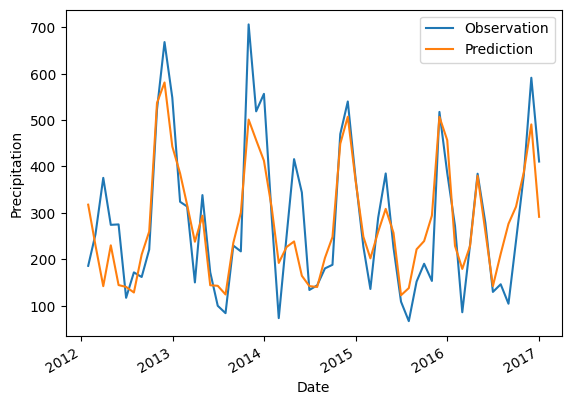

RMSE: 83.43
Correlation: 0.85


In [ ]:
 import os
from google.colab import drive
import os
import pandas as pd
import xarray as xr
drive.mount('/content/drive/')
path='/content/drive/My Drive/01_PCHS2s/'
os.listdir(path)
drsmtrecmwf=xr.open_dataset(path+'drsmtrecmwf1120.nc')
drsmtreccc=xr.open_dataset(path+'drsmtreccc1120.nc')
drsmtrjma=xr.open_dataset(path+'drsmtrjma1120.nc')
dobs=xr.open_dataset(path+'chirpssumatera.nc')
#dobs=xr.open_dataset(path+'chirpspapua.nc')
lon,lat=100,-0
dbkttg_ecmwf=drsmtrecmwf.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_eccc=drsmtreccc.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_jma=drsmtrjma.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_obs=dobs.sel(longitude=lon,latitude=lat,method='nearest')
dbkttg_ecmwfdf=dbkttg_ecmwf.to_dataframe()
dbkttg_ecccdf=dbkttg_eccc.to_dataframe()
dbkttg_jmadf=dbkttg_jma.to_dataframe()
dbkttg_obsdf=dbkttg_obs.to_dataframe()
dbkttg_ecmwfdf=dbkttg_ecmwfdf.loc[(dbkttg_ecmwfdf.index >= '2011-01-01') & (dbkttg_ecmwfdf.index <'2021-01-01')]
dbkttg_ecccdf=dbkttg_ecccdf.loc[(dbkttg_ecccdf.index >= '2011-01-01') & (dbkttg_ecccdf.index <'2021-01-01')]
dbkttg_jmadf=dbkttg_jmadf.loc[(dbkttg_jmadf.index >= '2011-01-01') & (dbkttg_jmadf.index <'2021-01-01')]
dbkttg_obsdf=dbkttg_obsdf.loc[(dbkttg_obsdf.index >= '2011-01-01') & (dbkttg_obsdf.index <'2021-01-01')]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Generate the date range from Jan 2010 to Dec 2020
# Load the dataset
data=pd.DataFrame()
data['ECMWF']=dbkttg_ecmwfdf.reset_index()['tprate']*86400000*30
data['ECCC']=dbkttg_ecccdf.reset_index()['tprate']*86400000*30
data['JMA']=dbkttg_jmadf.reset_index()['tprate']*86400000*30
data['Observation']=dbkttg_obsdf.reset_index()['precip']
data['Date'] = pd.date_range(start='2011-01', end='2021-01', freq='M')

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
import joblib
# Step 1: Generate the monthly time indices from Jan 2010 to Dec 2020
time_index = pd.date_range(start='2011-01-01', end='2021-01-01', freq='M')

# Step 2: Load and prepare the data for training
# Assuming you have the data in a single dataframe with columns 'Date', 'ECCC', 'ECMWF', 'JMA', and 'Observation'
# You might need to adjust the column names based on your data
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date').reindex(time_index)

# Step 3: Prepare the data for training
X = data[['ECCC', 'ECMWF', 'JMA']]
y = data['Observation']

# Step 4: Train the random forest model
#model = RandomForestRegressor(n_estimators=12,max_samples=36,max_features=12)#max_leaf_nodes=100,warm_start=True,max_depth=10,min_samples_leaf=10)
#model = MLPRegressor(solver='lbfgs',learning_rate='adaptive')#,hidden_layer_sizes=100)#RandomForestRegressor(max_leaf_nodes=8,warm_start=True,max_depth=9,min_samples_leaf=3)
#model.fit(X, y)
model = joblib.load(f'{path}RFR230714.pkl')
# Step 5: Predict and evaluate on the test period (Jan 2020 to Mar 2020)
test_start = pd.to_datetime('2012-01')
test_end = pd.to_datetime('2017-01')
test_data = data[(data.index >= test_start) & (data.index <= test_end)]
X_test = test_data[['ECCC', 'ECMWF', 'JMA']]
y_test = test_data['Observation']

y_pred = model.predict(X_test)

# Calculate RMSE and correlation
from sklearn.metrics import accuracy_score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
correlation = np.corrcoef(y_test, y_pred)[0, 1]
#accuracy = accuracy_score(y_test, y_pred)
# Step 6: Plot the predicted and observed precipitation
fig, ax = plt.subplots()
ax.plot(test_data.index, y_test, label='Observation')
ax.plot(test_data.index, y_pred, label='Prediction')
fig.autofmt_xdate()
plt.xlabel('Date')
plt.ylabel('Precipitation')
plt.legend()
plt.show()

# Print the RMSE and correlation
print(f'RMSE: {rmse:.2f}')
print(f'Correlation: {correlation:.2f}')
#print(f"Proportion of correct predictions: {accuracy}")

In [ ]:
from sklearn.metrics import accuracy_score

# Define true labels and predicted labels
true_labels = [1, 0, 1, 0, 1]
pred_labels = [1, 0, 0, 0, 1]

# Calculate the accuracy score
accuracy = accuracy_score(true_labels, pred_labels)

# Print the proportion of correct predictions
print(f"Proportion of correct predictions: {accuracy}")

Proportion of correct predictions: 0.8


In [ ]:
y_pred

array([317.70289485, 229.91603216, 141.95917575, 230.06341362,
       144.3624986 , 140.390824  , 128.34728368, 210.1357193 ,
       259.80284627, 536.86969503, 581.15323639, 443.18613688,
       385.25094096, 317.37548065, 237.78735352, 293.96791712,
       143.96937561, 142.7662646 , 124.09356944, 235.32044601,
       300.29196167, 501.18596141, 456.91172282, 412.47337596,
       310.84634145, 192.05849457, 226.32338969, 238.40248362,
       164.363849  , 142.08911705, 140.24857712, 202.9334844 ,
       247.94209544, 449.03115336, 507.31645203, 369.38709005,
       248.58719508, 201.97384389, 259.40696716, 308.63179016,
       257.05992254, 122.41713587, 137.85709445, 221.49009196,
       239.21182632, 294.14623896, 507.05549367, 456.90572103,
       228.87870153, 179.16057142, 228.74686305, 379.87549845,
       259.48392995, 142.04165777, 211.61832428, 276.37372589,
       313.37909444, 387.1995341 , 490.7303009 , 291.47192001])

In [ ]:
!pip install joblib
import joblib
joblib.dump(model,f'{path}RFR230714.pkl')
for i in koordinat:
  model.predict(i)

['/content/drive/My Drive/01_PCHS2s/RFR230714.pkl']